### Imports

In [ ]:
from pathlib import Path
from dataclasses import dataclass
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from __future__ import annotations

# Task 10

### Helpers

In [ ]:
@dataclass(slots=True)
class Visuals_config:
    project_root: Path

    @property
    def output_root(self) -> Path:
        return self.project_root / "outputs"

    @property
    def phase_d_root(self) -> Path:
        return self.output_root / "EDA_Visuals"

    @property
    def tables_dir(self) -> Path:
        return self.phase_d_root / "tables"

    @property
    def figures_dir(self) -> Path:
        return self.phase_d_root / "figures"

    @property
    def summaries_dir(self) -> Path:
        return self.phase_d_root / "summaries"

    @property
    def master_csv(self) -> Path:
        return self.output_root / "dataset_master.csv"

    @property
    def structure_features_csv(self) -> Path:
        return self.output_root / "structural_features" / "structure_features.csv"


def ensure_dirs(paths: Iterable[Path]) -> None:
    for path in paths:
        path.mkdir(parents=True, exist_ok=True)


def summarize_series(s: pd.Series, name: str) -> dict:
    s = pd.to_numeric(s, errors="coerce").dropna()

    if s.empty:
        return {
            "metric": name,
            "count": 0,
            "min": np.nan,
            "max": np.nan,
            "mean": np.nan,
            "std": np.nan,
            "median": np.nan,
            "q1": np.nan,
            "q3": np.nan,
        }

    return {
        "metric": name,
        "count": int(s.shape[0]),
        "min": float(s.min()),
        "max": float(s.max()),
        "mean": float(s.mean()),
        "std": float(s.std(ddof=0)),
        "median": float(s.median()),
        "q1": float(s.quantile(0.25)),
        "q3": float(s.quantile(0.75)),
    }


def save_table(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def save_text(text: str, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")


def finalize_and_save(fig_path: Path) -> None:
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.close()

### Load and merge data

In [ ]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
config = Visuals_config(project_root=PROJECT_ROOT)

ensure_dirs([
    config.phase_d_root,
    config.tables_dir,
    config.figures_dir,
    config.summaries_dir,
])

print("Master CSV:", config.master_csv)
print("Structure features CSV:", config.structure_features_csv)

Master CSV: D:\masters_project\outputs\dataset_master.csv
Structure features CSV: D:\masters_project\outputs\structural_features\structure_features.csv


In [5]:
df_master = pd.read_csv(config.master_csv)
df_feat = pd.read_csv(config.structure_features_csv)

for col in ["lower_rotation", "displacement", "upper_rotation", "energy", "delta_energy"]:
    if col in df_master.columns:
        df_master[col] = pd.to_numeric(df_master[col], errors="coerce")

for col in df_feat.columns:
    if col not in {"structure_id", "relative_cif_path"}:
        df_feat[col] = pd.to_numeric(df_feat[col], errors="coerce")

### Merge base dataframe

In [6]:
df = df_master.merge(
    df_feat,
    on=["structure_id", "relative_cif_path"],
    how="inner",
    validate="one_to_one",
)

df = df.sort_values(
    ["lower_rotation", "displacement", "upper_rotation"],
    na_position="last"
).reset_index(drop=True)

print("Merged shape:", df.shape)
df.head()

Merged shape: (2916, 60)


,structure_id,relative_cif_path,lower_rotation,displacement,upper_rotation,energy,delta_energy,atom_count,lower_atom_count,upper_atom_count,...,nn_min,nn_max,lower_nn_mean,lower_nn_std,lower_nn_min,lower_nn_max,upper_nn_mean,upper_nn_std,upper_nn_min,upper_nn_max
0,L0_D0_U0,r0/t0/t0_0.cif,0.0,0.0,0.0,-936.50959,0.13021,156,78,78,...,0.977309,2.003689,1.134992,0.166349,0.977309,2.003689,1.118772,0.128105,0.977336,1.447277
1,L0_D0_U20,r0/t0/t0_20.cif,0.0,0.0,20.0,-936.45119,0.18861,156,78,78,...,0.977445,2.015780,1.135293,0.167320,0.977445,2.015780,1.118620,0.127984,0.977486,1.443505
2,L0_D0_U40,r0/t0/t0_40.cif,0.0,0.0,40.0,-936.20394,0.43586,156,78,78,...,0.977271,2.022419,1.135341,0.167675,0.977619,2.022419,1.118703,0.127710,0.977271,1.441318
3,L0_D0_U60,r0/t0/t0_60.cif,0.0,0.0,60.0,-936.12172,0.51808,156,78,78,...,0.977377,2.001180,1.135072,0.166242,0.977546,2.001180,1.118664,0.127767,0.977377,1.442334
4,L0_D0_U80,r0/t0/t0_80.cif,0.0,0.0,80.0,-936.10592,0.53388,156,78,78,...,0.977302,2.032327,1.135514,0.168532,0.977785,2.032327,1.118726,0.128309,0.977302,1.445004


### Coordinate range analysis

In [7]:
coordinate_cols = [
    "lower_centroid_x",
    "lower_centroid_y",
    "lower_centroid_z",
    "upper_centroid_x",
    "upper_centroid_y",
    "upper_centroid_z",
    "lower_com_x",
    "lower_com_y",
    "lower_com_z",
    "upper_com_x",
    "upper_com_y",
    "upper_com_z",
]

coordinate_rows = [
    summarize_series(df[col], col)
    for col in coordinate_cols
    if col in df.columns
]

coordinate_ranges = pd.DataFrame(coordinate_rows)
coordinate_ranges

,metric,count,min,max,mean,std,median,q1,q3
0,lower_centroid_x,2916,8.504154,10.309422,9.542111,0.152465,9.543952,9.484884,9.606685
1,lower_centroid_y,2916,5.094608,6.369789,5.617686,0.158993,5.606951,5.535073,5.701880
2,lower_centroid_z,2916,3.874692,7.318677,5.210642,0.557039,4.882916,4.829837,5.640865
3,upper_centroid_x,2916,6.966450,12.067246,9.176330,0.539024,9.191702,8.843387,9.499613
4,upper_centroid_y,2916,3.266590,6.020896,4.529818,0.348903,4.523252,4.299631,4.732542
5,upper_centroid_z,2916,10.389995,14.612559,12.677057,0.821899,12.506262,12.010438,13.368850
6,lower_com_x,2916,8.340169,10.044538,9.412558,0.164757,9.418418,9.359486,9.479980
7,lower_com_y,2916,5.075005,6.450685,5.619342,0.164610,5.610224,5.519260,5.717259
8,lower_com_z,2916,3.795140,7.469644,5.210081,0.566264,4.914321,4.804464,5.660249
9,upper_com_x,2916,6.798692,12.111550,9.134805,0.541219,9.149827,8.806303,9.468298


### Distance summary analysis

In [8]:
distance_cols = [
    "centroid_separation",
    "com_separation",
    "lower_intralayer_dist_mean",
    "lower_intralayer_dist_std",
    "lower_intralayer_dist_min",
    "lower_intralayer_dist_max",
    "upper_intralayer_dist_mean",
    "upper_intralayer_dist_std",
    "upper_intralayer_dist_min",
    "upper_intralayer_dist_max",
    "interlayer_dist_mean",
    "interlayer_dist_std",
    "interlayer_dist_min",
    "interlayer_dist_max",
    "nn_mean",
    "nn_std",
    "nn_min",
    "nn_max",
    "lower_nn_mean",
    "upper_nn_mean",
]

distance_rows = [
    summarize_series(df[col], col)
    for col in distance_cols
    if col in df.columns
]

distance_summary = pd.DataFrame(distance_rows)
distance_summary

,metric,count,min,max,mean,std,median,q1,q3
0,centroid_separation,2916,4.991956,9.795618,7.569754,0.940398,7.506260,6.920649,8.278606
1,com_separation,2916,5.058615,9.954583,7.568462,0.948539,7.498829,6.929092,8.238285
2,lower_intralayer_dist_mean,2916,7.160992,7.339437,7.208365,0.014299,7.206447,7.200680,7.212830
3,lower_intralayer_dist_std,2916,3.809381,3.987551,3.878573,0.011968,3.877159,3.871987,3.883055
4,lower_intralayer_dist_min,2916,0.974667,0.978964,0.977398,0.000289,0.977410,0.977275,0.977525
5,lower_intralayer_dist_max,2916,17.967492,19.819741,18.167463,0.134982,18.144151,18.130092,18.159828
6,upper_intralayer_dist_mean,2916,7.171007,7.416815,7.277704,0.052794,7.295433,7.214435,7.313777
7,upper_intralayer_dist_std,2916,3.845050,4.048418,3.946286,0.049396,3.961506,3.887067,3.982903
8,upper_intralayer_dist_min,2916,0.974645,0.978946,0.977414,0.000324,0.977420,0.977299,0.977538
9,upper_intralayer_dist_max,2916,17.911887,20.851286,18.680025,0.454963,18.772600,18.147343,19.045099


### Atom composition / contact proxy summary

In [9]:
atom_cols = [
    "count_C",
    "count_H",
    "count_O",
    "lower_count_C",
    "lower_count_H",
    "lower_count_O",
    "upper_count_C",
    "upper_count_H",
    "upper_count_O",
]

available_atom_cols = [c for c in atom_cols if c in df.columns]

atom_contact_proxy = (
    df[available_atom_cols]
    .agg(["min", "max", "mean", "std"])
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

atom_contact_proxy

,feature,min,max,mean,std
0,count_C,48.0,48.0,48.000000,0.000000
1,count_H,72.0,72.0,72.000000,0.000000
2,count_O,36.0,36.0,36.000000,0.000000
3,lower_count_C,24.0,24.0,24.000000,0.000000
4,lower_count_H,34.0,38.0,35.998628,0.148167
5,lower_count_O,16.0,20.0,18.001372,0.148167
6,upper_count_C,24.0,24.0,24.000000,0.000000
7,upper_count_H,34.0,38.0,36.001372,0.148167
8,upper_count_O,16.0,20.0,17.998628,0.148167


### Geometric change across rotations and displacements

In [10]:
geometry_metrics = [
    "centroid_separation",
    "com_separation",
    "interlayer_dist_mean",
    "interlayer_dist_min",
    "interlayer_dist_max",
    "nn_mean",
]
geometry_metrics = [m for m in geometry_metrics if m in df.columns]

rotation_disp_geometry = (
    df.groupby(["lower_rotation", "displacement", "upper_rotation"], dropna=False)[geometry_metrics]
    .mean()
    .reset_index()
    .sort_values(["lower_rotation", "displacement", "upper_rotation"])
    .reset_index(drop=True)
)

rotation_disp_geometry.head()

,lower_rotation,displacement,upper_rotation,centroid_separation,com_separation,interlayer_dist_mean,interlayer_dist_min,interlayer_dist_max,nn_mean
0,0.0,0.0,0.0,7.894709,7.893190,10.786389,2.178062,20.937344,1.126882
1,0.0,0.0,20.0,8.084154,8.087593,10.935037,2.450119,21.004836,1.126957
2,0.0,0.0,40.0,8.686132,8.707625,11.423664,2.203444,21.273854,1.127022
3,0.0,0.0,60.0,8.278125,8.323214,11.125739,2.347058,21.002145,1.126868
4,0.0,0.0,80.0,7.350004,7.421266,10.454967,2.533589,21.149924,1.127120


### histogram of interatomic distances

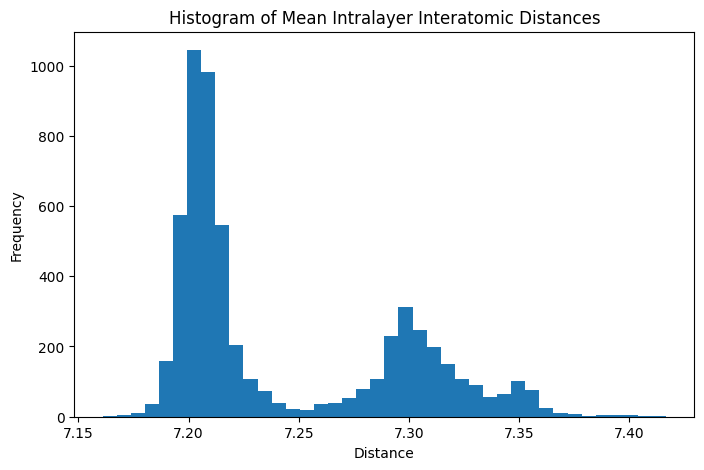

In [11]:
interatomic_arrays = []

for col in ["lower_intralayer_dist_mean", "upper_intralayer_dist_mean"]:
    if col in df.columns:
        vals = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy()
        if len(vals) > 0:
            interatomic_arrays.append(vals)

if interatomic_arrays:
    interatomic_data = np.concatenate(interatomic_arrays)

    plt.figure(figsize=(8, 5))
    plt.hist(interatomic_data, bins=40)
    plt.title("Histogram of Mean Intralayer Interatomic Distances")
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("No intralayer distance columns available for plotting.")

### histogram of interlayer distances

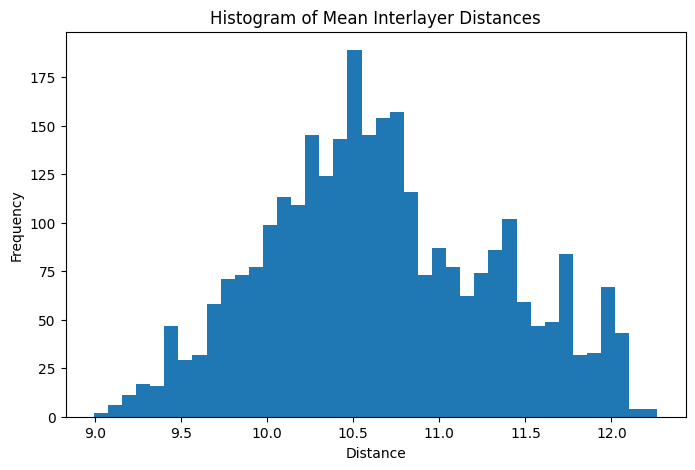

In [12]:
if "interlayer_dist_mean" in df.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df["interlayer_dist_mean"].dropna(), bins=40)
    plt.title("Histogram of Mean Interlayer Distances")
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("Column 'interlayer_dist_mean' not found.")

### displacement vs centroid separation

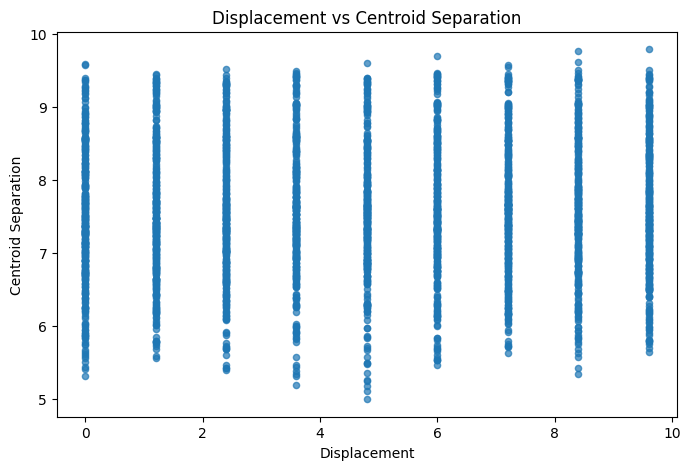

In [13]:
if {"displacement", "centroid_separation"}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    plt.scatter(
        df["displacement"],
        df["centroid_separation"],
        alpha=0.7,
        s=20,
    )
    plt.title("Displacement vs Centroid Separation")
    plt.xlabel("Displacement")
    plt.ylabel("Centroid Separation")
    plt.show()
else:
    print("Required columns for scatter plot not found.")

### Saving tables, graphs and summary at end

In [14]:
save_table(coordinate_ranges, config.tables_dir / "coordinate_ranges.csv")
save_table(distance_summary, config.tables_dir / "distance_summary.csv")
save_table(atom_contact_proxy, config.tables_dir / "atom_contact_proxy_summary.csv")
save_table(rotation_disp_geometry, config.tables_dir / "rotation_displacement_geometry.csv")

print("Tables saved.")

Tables saved.


In [16]:
# Figure 1
if interatomic_arrays:
    interatomic_data = np.concatenate(interatomic_arrays)
    plt.figure(figsize=(8, 5))
    plt.hist(interatomic_data, bins=40)
    plt.title("Histogram of Mean Intralayer Interatomic Distances")
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    finalize_and_save(config.figures_dir / "hist_interatomic_distances.png")

# Figure 2
if "interlayer_dist_mean" in df.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df["interlayer_dist_mean"].dropna(), bins=40)
    plt.title("Histogram of Mean Interlayer Distances")
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    finalize_and_save(config.figures_dir / "hist_interlayer_distances.png")

# Figure 3
if {"displacement", "centroid_separation"}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    plt.scatter(
        df["displacement"],
        df["centroid_separation"],
        alpha=0.7,
        s=20,
    )
    plt.title("Displacement vs Centroid Separation")
    plt.xlabel("Displacement")
    plt.ylabel("Centroid Separation")
    finalize_and_save(config.figures_dir / "scatter_displacement_vs_centroid_separation.png")

print("figures saved.")

figures saved.


In [17]:
lines = []
lines.append("Geometric Statistics Summary")
lines.append("=" * 48)
lines.append(f"Total structures analysed: {len(df)}")

for col in ["centroid_separation", "com_separation", "interlayer_dist_mean", "nn_mean"]:
    if col in df.columns:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if not s.empty:
            lines.append(
                f"{col}: min={s.min():.4f}, max={s.max():.4f}, "
                f"mean={s.mean():.4f}, std={s.std(ddof=0):.4f}"
            )

if {"displacement", "centroid_separation"}.issubset(df.columns):
    corr = df["displacement"].corr(df["centroid_separation"])
    lines.append(f"Correlation(displacement, centroid_separation): {corr:.4f}")

if {"lower_rotation", "interlayer_dist_mean"}.issubset(df.columns):
    corr = df["lower_rotation"].corr(df["interlayer_dist_mean"])
    lines.append(f"Correlation(lower_rotation, interlayer_dist_mean): {corr:.4f}")

if {"upper_rotation", "interlayer_dist_mean"}.issubset(df.columns):
    corr = df["upper_rotation"].corr(df["interlayer_dist_mean"])
    lines.append(f"Correlation(upper_rotation, interlayer_dist_mean): {corr:.4f}")

summary_text = "\n".join(lines)
print(summary_text)

Geometric Statistics Summary
Total structures analysed: 2916
centroid_separation: min=4.9920, max=9.7956, mean=7.5698, std=0.9404
com_separation: min=5.0586, max=9.9546, mean=7.5685, std=0.9485
interlayer_dist_mean: min=8.9926, max=12.2674, mean=10.6638, std=0.6677
nn_mean: min=1.1185, max=1.1770, mean=1.1361, std=0.0090
Correlation(displacement, centroid_separation): 0.0451
Correlation(lower_rotation, interlayer_dist_mean): -0.1499
Correlation(upper_rotation, interlayer_dist_mean): -0.2858


# Task 11

### Visuals of Energy values

In [20]:
energy = pd.to_numeric(df["energy"], errors="coerce").dropna()
delta_energy = pd.to_numeric(df["delta_energy"], errors="coerce").dropna()

print("Valid energy values:", len(energy))
print("Valid delta energy values:", len(delta_energy))

Valid energy values: 2916
Valid delta energy values: 2916


### Summary statistics

In [21]:
energy_summary = pd.DataFrame([
    {
        "metric": "energy",
        "count": int(energy.shape[0]),
        "min": float(energy.min()),
        "max": float(energy.max()),
        "mean": float(energy.mean()),
        "std": float(energy.std(ddof=0)),
        "median": float(energy.median()),
        "q1": float(energy.quantile(0.25)),
        "q3": float(energy.quantile(0.75)),
    },
    {
        "metric": "delta_energy",
        "count": int(delta_energy.shape[0]),
        "min": float(delta_energy.min()),
        "max": float(delta_energy.max()),
        "mean": float(delta_energy.mean()),
        "std": float(delta_energy.std(ddof=0)),
        "median": float(delta_energy.median()),
        "q1": float(delta_energy.quantile(0.25)),
        "q3": float(delta_energy.quantile(0.75)),
    },
])

energy_summary

,metric,count,min,max,mean,std,median,q1,q3
0,energy,2916,-937.24928,-935.9060,-936.314189,0.235931,-936.25674,-936.432413,-936.141387
1,delta_energy,2916,-0.60948,0.7338,0.325611,0.235931,0.38306,0.207388,0.498413


### Outlier analysis

In [22]:
def iqr_outlier_summary(series: pd.Series, metric_name: str) -> dict:
    s = pd.to_numeric(series, errors="coerce").dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = s[(s < lower_bound) | (s > upper_bound)]

    return {
        "metric": metric_name,
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(iqr),
        "lower_bound": float(lower_bound),
        "upper_bound": float(upper_bound),
        "outlier_count": int(outliers.shape[0]),
        "outlier_fraction": float(outliers.shape[0] / s.shape[0]),
    }

outlier_summary = pd.DataFrame([
    iqr_outlier_summary(df["energy"], "energy"),
    iqr_outlier_summary(df["delta_energy"], "delta_energy"),
])

outlier_summary

,metric,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_fraction
0,energy,-936.432413,-936.141387,0.291025,-936.86895,-935.70485,118,0.040466
1,delta_energy,0.207388,0.498413,0.291025,-0.22915,0.93495,118,0.040466


# Task 12

In [30]:
required_cols = ["lower_rotation", "upper_rotation", "displacement", "energy"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns for Task 19: {missing}")

task19_df = df[required_cols].copy()

for col in required_cols:
    task19_df[col] = pd.to_numeric(task19_df[col], errors="coerce")

task19_df = task19_df.dropna().reset_index(drop=True)

print("Task 19 rows:", len(task19_df))
task19_df.head()

Task 19 rows: 2916


,lower_rotation,upper_rotation,displacement,energy
0,0.0,0.0,0.0,-936.50959
1,0.0,20.0,0.0,-936.45119
2,0.0,40.0,0.0,-936.20394
3,0.0,60.0,0.0,-936.12172
4,0.0,80.0,0.0,-936.10592


In [31]:
lower_rotation_energy = (
    task19_df.groupby("lower_rotation", as_index=False)["energy"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)

upper_rotation_energy = (
    task19_df.groupby("upper_rotation", as_index=False)["energy"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)

displacement_energy = (
    task19_df.groupby("displacement", as_index=False)["energy"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)

lower_rotation_energy

,index,lower_rotation,mean,std,min,max,count
0,0,0.0,-936.286113,0.195456,-936.78495,-935.90600,162
1,1,20.0,-936.246598,0.157264,-936.79168,-935.99827,162
2,2,40.0,-936.178338,0.110457,-936.77220,-935.99594,162
3,3,60.0,-936.124017,0.125663,-936.73208,-935.99130,162
4,4,80.0,-936.441558,0.263674,-937.21295,-935.99628,162
5,5,100.0,-936.372014,0.284252,-937.24928,-935.94891,162
6,6,120.0,-936.177545,0.102554,-936.42103,-935.97728,162
7,7,140.0,-936.185192,0.089496,-936.42423,-935.99648,162
8,8,160.0,-936.284991,0.172594,-936.93921,-936.01898,162
9,9,180.0,-936.348417,0.230212,-937.04962,-935.99057,162


In [33]:
pivot_lower_upper = task19_df.pivot_table(
    index="lower_rotation",
    columns="upper_rotation",
    values="energy",
    aggfunc="mean"
)

pivot_lower_disp = task19_df.pivot_table(
    index="lower_rotation",
    columns="displacement",
    values="energy",
    aggfunc="mean"
)

pivot_upper_disp = task19_df.pivot_table(
    index="upper_rotation",
    columns="displacement",
    values="energy",
    aggfunc="mean"
)

pivot_lower_upper

upper_rotation,0.0,20.0,40.0,60.0,80.0,100.0,120.0,140.0,160.0,180.0,200.0,220.0,240.0,260.0,280.0,300.0,320.0,340.0
lower_rotation,,,,,,,,,,,,,,,,,,
0.0,-936.365950,-936.206606,-936.110440,-936.160101,-936.234686,-936.412489,-936.364546,-936.313366,-936.154709,-936.114284,-936.125443,-936.348431,-936.510796,-936.404637,-936.303157,-936.306992,-936.377339,-936.336061
20.0,-936.265064,-936.195040,-936.140767,-936.165369,-936.202520,-936.292739,-936.340180,-936.264396,-936.153211,-936.102489,-936.083181,-936.165871,-936.309398,-936.455332,-936.306293,-936.332666,-936.319700,-936.344547
40.0,-936.156166,-936.098511,-936.085660,-936.181744,-936.206002,-936.238382,-936.265762,-936.158150,-936.094654,-936.078837,-936.069261,-936.111224,-936.199878,-936.206711,-936.160074,-936.257148,-936.338574,-936.303339
60.0,-936.105857,-936.047264,-936.034049,-936.103974,-936.124718,-936.211194,-936.161583,-936.106618,-936.071502,-936.034772,-936.024988,-936.053133,-936.128010,-936.095622,-936.093079,-936.219970,-936.350734,-936.265239
80.0,-936.342628,-936.220374,-936.154960,-936.481358,-936.794397,-936.831536,-936.458668,-936.224629,-936.263091,-936.380360,-936.469792,-936.604036,-936.689570,-936.442361,-936.510562,-936.385388,-936.354178,-936.340153
100.0,-936.203752,-936.158744,-936.212920,-936.332603,-936.727613,-936.521006,-936.351658,-936.214551,-936.143659,-936.205623,-936.487147,-936.785657,-936.689054,-936.470857,-936.376424,-936.290942,-936.262401,-936.261637
120.0,-936.102664,-936.091836,-936.129968,-936.188699,-936.127572,-936.255050,-936.302663,-936.221276,-936.139340,-936.114268,-936.049276,-936.078651,-936.187494,-936.285648,-936.273584,-936.216331,-936.211758,-936.219736
140.0,-936.157553,-936.048793,-936.129418,-936.218534,-936.225089,-936.187496,-936.231170,-936.275834,-936.190571,-936.125104,-936.144674,-936.166316,-936.183530,-936.181693,-936.234833,-936.258557,-936.233579,-936.140706
160.0,-936.230526,-936.201453,-936.057010,-936.140667,-936.288743,-936.345829,-936.346737,-936.341839,-936.362433,-936.240866,-936.150743,-936.208963,-936.264924,-936.304990,-936.313703,-936.493014,-936.545770,-936.291628


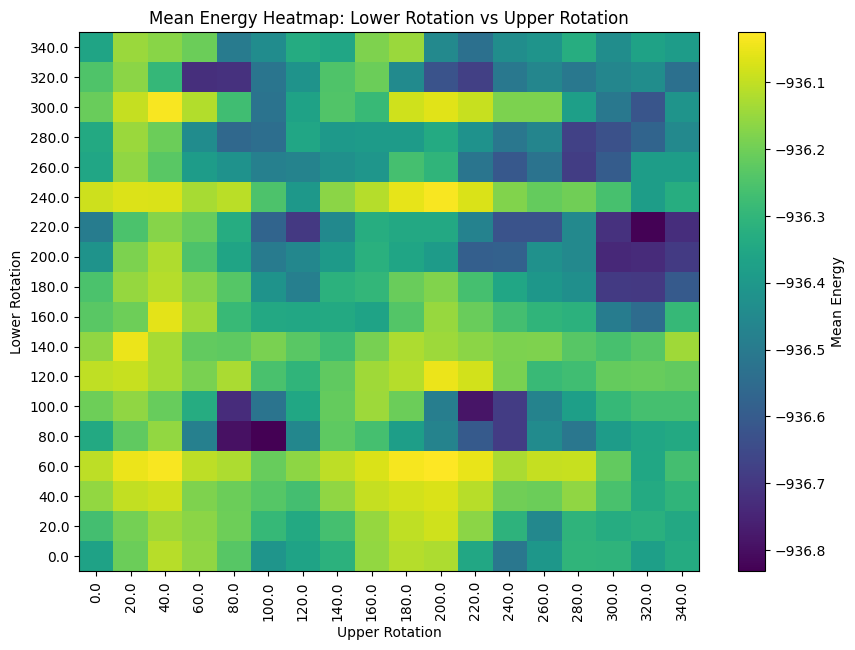

In [39]:
plt.figure(figsize=(10, 7))
plt.imshow(pivot_lower_upper, aspect="auto", origin="lower")
plt.colorbar(label="Mean Energy")
plt.title("Mean Energy Heatmap: Lower Rotation vs Upper Rotation")
plt.xlabel("Upper Rotation")
plt.ylabel("Lower Rotation")
plt.xticks(range(len(pivot_lower_upper.columns)), pivot_lower_upper.columns, rotation=90)
plt.yticks(range(len(pivot_lower_upper.index)), pivot_lower_upper.index)
plt.show()